In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA = 'data'

# ===== 主表：資産・負債 =====
df1 = pd.read_excel(f'{DATA}/111.xlsx', sheet_name='sheet1', dtype={'id':str})
df1 = df1[df1['type']=='A'].copy()
df1['date'] = pd.to_datetime(df1['date'])
df1 = df1[(df1['date'].dt.month==12)&(df1['date'].dt.day==31)].copy()
df1['year'] = df1['date'].dt.year
cn = df1[['id','year','AT','AR','AI','Bc1','BL','Liudongfuzhaiheji']].rename(columns={
    'AT':'total_assets','AR':'accounts_receivable','AI':'inventory',
    'Bc1':'short_borrow','BL':'long_debt','Liudongfuzhaiheji':'current_liab'})

# ===== EBIT =====
df2 = pd.read_excel(f'{DATA}/222.xlsx', sheet_name='sheet2', dtype={'id':str})
df2 = df2[df2['type']=='A'].copy()
df2['date'] = pd.to_datetime(df2['date'])
df2 = df2[(df2['date'].dt.month==12)&(df2['date'].dt.day==31)].copy()
df2['year'] = df2['date'].dt.year
ebit = df2[['id','year','EBIT']].copy()
ebit['EBIT'] = pd.to_numeric(ebit['EBIT'], errors='coerce')
cn = pd.merge(cn, ebit, on=['id','year'], how='left')

# ===== 利息 =====
rc_raw = pd.read_excel(f'{DATA}/rc_interest.xlsx', header=1)
rc_raw.columns = ['Stkcd','Accper','Typrep','Sgnyea','item','amount']
rc_raw = rc_raw[~rc_raw['Stkcd'].isin(['证券代码','没有单位'])].copy()
rc_raw['Accper'] = pd.to_datetime(rc_raw['Accper'])
rc_raw = rc_raw[(rc_raw['Typrep']==1)&(rc_raw['Sgnyea']==1)&(rc_raw['Accper'].dt.month==12)].copy()
rc_raw['year'] = rc_raw['Accper'].dt.year
rc_raw['item'] = pd.to_numeric(rc_raw['item'], errors='coerce')
rc_raw['amount'] = pd.to_numeric(rc_raw['amount'], errors='coerce')
ie = rc_raw[rc_raw['item']==2][['Stkcd','year','amount']].rename(columns={'amount':'ie'})
ii = rc_raw[rc_raw['item']==3][['Stkcd','year','amount']].rename(columns={'amount':'ii'})
rc = pd.merge(ie, ii, on=['Stkcd','year'], how='outer')
rc = rc.groupby(['Stkcd','year']).agg(ie=('ie','max'), ii=('ii','max')).reset_index()
rc['interest'] = rc['ie'].fillna(0) - rc['ii'].fillna(0)
rc['id'] = rc['Stkcd'].astype(str).str.zfill(6)
cn = pd.merge(cn, rc[['id','year','interest']], on=['id','year'], how='left')

# ===== 【新規】損益計算書：営業収入・純利益 =====
inc = pd.read_excel(f'{DATA}/FS_Comins.xlsx')
inc = inc[~inc['Stkcd'].isin(['证券代码','没有单位'])].copy()
inc = inc[inc['Typrep']=='A'].copy()  # 合併財務諸表
inc['Accper'] = pd.to_datetime(inc['Accper'], errors='coerce')
inc = inc[(inc['Accper'].dt.month==12)&(inc['Accper'].dt.day==31)].copy()
inc['year'] = inc['Accper'].dt.year
inc['revenue']    = pd.to_numeric(inc['B001101000'], errors='coerce')  # 営業収入
inc['net_income'] = pd.to_numeric(inc['B002000000'], errors='coerce')  # 純利益
inc['id'] = inc['Stkcd'].astype(str).str.zfill(6)
cn = pd.merge(cn, inc[['id','year','revenue','net_income']], on=['id','year'], how='left')

# ===== 【新規】業種コード =====
ind = pd.read_excel(f'{DATA}/FI_T10.xlsx', dtype={'Stkcd':str})
ind = ind[~ind['Stkcd'].isin(['股票代码','没有单位'])].copy()
ind = ind[ind['Indcd'].notna()].copy()
ind['Accper'] = pd.to_datetime(ind['Accper'], errors='coerce')
ind = ind.sort_values('Accper').groupby('Stkcd').tail(1)  # 各企業の最新の業種
ind['id'] = ind['Stkcd'].astype(str).str.zfill(6)
ind['ind_major'] = ind['Indcd'].str[0]  # 首字母＝大分類
cn = pd.merge(cn, ind[['id','ind_major']], on='id', how='left')

# 数値型変換
for c in ['total_assets','accounts_receivable','inventory','short_borrow','long_debt','current_liab']:
    cn[c] = pd.to_numeric(cn[c], errors='coerce')
cn['firm'] = 'CN_' + cn['id'].astype(str)

print(f'統合完了: {len(cn)}行, {cn["firm"].nunique()}社')
print(f'業種大分類の分布:')
print(cn.drop_duplicates('firm')['ind_major'].value_counts().head(10))
print(f'\n営業収入の欠損率: {cn["revenue"].isna().mean()*100:.1f}%')
print(f'純利益の欠損率: {cn["net_income"].isna().mean()*100:.1f}%')

統合完了: 35350行, 5617社
業種大分類の分布:
ind_major
C    3315
I     421
F     196
D     134
J     131
K     122
G     118
E     112
M     106
N      95
Name: count, dtype: int64

営業収入の欠損率: 6.4%
純利益の欠損率: 4.5%


In [3]:
# ===== ラグ変数 =====
cn = cn.sort_values(['firm','year']).reset_index(drop=True)
lag = cn[['firm','year','short_borrow','long_debt','total_assets',
          'accounts_receivable','inventory','current_liab']].copy()
lag['year'] = lag['year'] + 1
lag = lag.rename(columns={'short_borrow':'short_borrow_lag','long_debt':'long_debt_lag',
    'total_assets':'total_assets_lag','accounts_receivable':'ar_lag',
    'inventory':'inventory_lag','current_liab':'current_liab_lag'})
cn = pd.merge(cn, lag, on=['firm','year'], how='left')

# ===== 基準利息（中国：人民銀行金利）=====
cn['Rstar'] = cn['short_borrow_lag'].fillna(0)*0.0435 + cn['long_debt_lag'].fillna(0)*0.0475
cn['RB'] = (cn['total_assets_lag'].fillna(0)-cn['ar_lag'].fillna(0)-cn['inventory_lag'].fillna(0))*0.015
cn['gap'] = cn['interest'] - (cn['Rstar'] - cn['RB'])

# ===== FN-CHKゾンビラベル =====
cn['gapm'] = cn['EBIT'] - (cn['Rstar'] - cn['RB'])
cn['debt_lag'] = cn['current_liab_lag'].fillna(0) + cn['long_debt_lag'].fillna(0)
cn['CHK'] = (cn['gap'] < 0).astype(int)
cond1 = (cn['CHK']==1) & (cn['gapm']<=0)
cond2 = (cn['gapm']<=0) & (cn['debt_lag'] >= 0.5*cn['total_assets_lag'])
cn['zombie'] = (cond1 | cond2).astype(int)

# ===== 時間ずらし（t特徴 → t+1ラベル）=====
nxt = cn[['firm','year','zombie']].copy()
nxt['year'] = nxt['year'] - 1
nxt = nxt.rename(columns={'zombie':'label'})
cn = pd.merge(cn, nxt, on=['firm','year'], how='left')
ml = cn[cn['label'].notna()].copy()
ml['label'] = ml['label'].astype(int)

print(f'学習可能サンプル: {len(ml)}行')
print(f'正例（翌年ゾンビ化）: {int(ml["label"].sum())} ({ml["label"].mean()*100:.1f}%)')

学習可能サンプル: 29732行
正例（翌年ゾンビ化）: 2724 (9.2%)


In [4]:
# ============================================================
# 特徴量エンジニアリング（深化版：営業収入・業種を活用）
# ============================================================

# ----- 版本一と同じ基礎特徴量 -----
ml['total_debt'] = ml['current_liab'].fillna(0) + ml['long_debt'].fillna(0)
ml['debt_ratio'] = ml['total_debt'] / ml['total_assets']
ml['long_debt_ratio'] = ml['long_debt'] / ml['total_debt']
ml['long_debt_asset'] = ml['long_debt'] / ml['total_assets']
ml['short_borrow_dep'] = ml['short_borrow'] / ml['total_assets']

ml['interest_debt'] = ml['short_borrow'].fillna(0) + ml['long_debt'].fillna(0)
ml['implied_rate'] = ml['interest'] / ml['interest_debt']
ml['interest_gap'] = ml['gap'] / ml['total_assets']
ml['interest_coverage'] = ml['EBIT'] / ml['interest']
ml['interest_burden'] = ml['interest'] / ml['total_assets']

ml['roa'] = ml['EBIT'] / ml['total_assets']
ml['ebit_negative'] = (ml['EBIT'] < 0).astype(int)
ml['inventory_ratio'] = ml['inventory'] / ml['total_assets']

# ----- 【新規A】収益性（営業収入を活用したDuPont分解）-----
ml['net_margin']       = ml['net_income'] / ml['revenue']      # 純利益率
ml['ebit_margin']      = ml['EBIT'] / ml['revenue']            # EBIT率（本業の収益性）
ml['asset_turnover']   = ml['revenue'] / ml['total_assets']    # 総資産回転率（DuPontの鍵）
ml['ni_ebit_gap']      = (ml['net_income'] - ml['EBIT']) / ml['total_assets']  # 純利益とEBITの乖離（債務免除益の検出）

# ----- トレンド特徴量（版本一と同じ）-----
ml = ml.sort_values(['firm','year']).reset_index(drop=True)
ml['roa_change'] = ml.groupby('firm')['roa'].diff()
ml['debt_growth'] = ml.groupby('firm')['total_debt'].pct_change()
ml['interest_growth'] = ml.groupby('firm')['interest'].pct_change()
ml['ebit_growth'] = ml.groupby('firm')['EBIT'].pct_change()

def consecutive_loss(s):
    result, cnt = [], 0
    for v in s:
        cnt = cnt + 1 if v < 0 else 0
        result.append(cnt)
    return result
ml['loss_years'] = ml.groupby('firm')['EBIT'].transform(consecutive_loss)
ml['roa_volatility'] = ml.groupby('firm')['roa'].transform(lambda x: x.rolling(3, min_periods=2).std())

# ----- 【新規B】成長性（あなたの「見せかけの成長」洞察）-----
ml['revenue_growth'] = ml.groupby('firm')['revenue'].pct_change()          # 売上成長率
ml['ar_growth'] = ml.groupby('firm')['accounts_receivable'].pct_change()   # 売掛金成長率
ml['ar_rev_gap'] = ml['ar_growth'] - ml['revenue_growth']  # 売掛金成長 − 売上成長（見せかけの成長の検出）

# ----- 【新規C】業種フラグ（高新「偽ゾンビ」問題への対処）-----
# 高研究開発業種：I(情報技術), C27(医薬), C39(電子)など
high_tech = ['I','M']  # I=情報伝送・ソフト, M=科学研究
ml['is_hightech'] = ml['ind_major'].isin(high_tech).astype(int)
# 金融業：J(金融)
ml['is_financial'] = (ml['ind_major'] == 'J').astype(int)

# ----- クリーニング：inf→NaN、Winsorization -----
feature_cols = [
    'debt_ratio','long_debt_ratio','long_debt_asset','short_borrow_dep',
    'implied_rate','interest_gap','interest_coverage','interest_burden',
    'roa','inventory_ratio',
    'net_margin','ebit_margin','asset_turnover','ni_ebit_gap',   # 新規A
    'roa_change','debt_growth','interest_growth','ebit_growth','roa_volatility',
    'revenue_growth','ar_growth','ar_rev_gap',                    # 新規B
]
ml[feature_cols] = ml[feature_cols].replace([np.inf, -np.inf], np.nan)
for col in feature_cols:
    low, high = ml[col].quantile(0.01), ml[col].quantile(0.99)
    ml[col] = ml[col].clip(lower=low, upper=high)

# 最終特徴量リスト（数値 + フラグ）
all_features = feature_cols + ['ebit_negative','loss_years','is_hightech','is_financial']

print(f'特徴量の総数: {len(all_features)}')
print(f'  版本一より追加: 純利益率, EBIT率, 総資産回転率, 純利益-EBIT乖離,')
print(f'                売上成長率, 売掛金成長率, 売掛-売上乖離, 高新フラグ, 金融フラグ')
print(f'\nサンプル数: {len(ml)}, 正例率: {ml["label"].mean()*100:.1f}%')
print(f'\n新規特徴量の統計:')
print(ml[['net_margin','ebit_margin','asset_turnover','ar_rev_gap']].describe().round(3))

特徴量の総数: 26
  版本一より追加: 純利益率, EBIT率, 総資産回転率, 純利益-EBIT乖離,
                売上成長率, 売掛金成長率, 売掛-売上乖離, 高新フラグ, 金融フラグ

サンプル数: 29732, 正例率: 9.2%

新規特徴量の統計:
       net_margin  ebit_margin  asset_turnover  ar_rev_gap
count   27802.000    27802.000       27803.000   22687.000
mean        0.046        0.064           0.585       0.080
std         0.277        0.289           0.400       0.696
min        -1.721       -1.720           0.047      -1.588
25%         0.023        0.029           0.328      -0.184
50%         0.073        0.086           0.500       0.003
75%         0.142        0.167           0.725       0.206
max         0.579        0.684           2.454       4.593


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score

# 時系列分割
train = ml[ml['year'] <= 2020].copy()
test  = ml[ml['year'] >= 2021].copy()
X_train, y_train = train[all_features], train['label']
X_test,  y_test  = test[all_features],  test['label']
print(f'訓練: {len(X_train)}行 (正例率{y_train.mean()*100:.1f}%) / テスト: {len(X_test)}行 (正例率{y_test.mean()*100:.1f}%)')

neg, pos = (y_train==0).sum(), (y_train==1).sum()
spw = neg / pos
results = {}

# ロジスティック回帰
imp, scl = SimpleImputer(strategy='median'), StandardScaler()
Xtr = scl.fit_transform(imp.fit_transform(X_train))
Xte = scl.transform(imp.transform(X_test))
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(Xtr, y_train)
p = lr.predict_proba(Xte)[:,1]
results['ロジスティック回帰'] = (roc_auc_score(y_test,p), average_precision_score(y_test,p))

# ランダムフォレスト
Xtr_rf, Xte_rf = imp.fit_transform(X_train), imp.transform(X_test)
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(Xtr_rf, y_train)
p = rf.predict_proba(Xte_rf)[:,1]
results['ランダムフォレスト'] = (roc_auc_score(y_test,p), average_precision_score(y_test,p))

# XGBoost
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                    scale_pos_weight=spw, eval_metric='aucpr', random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
p = xgb.predict_proba(X_test)[:,1]
results['XGBoost'] = (roc_auc_score(y_test,p), average_precision_score(y_test,p))

print('='*50)
print(f'{"モデル":<20}{"AUC":>10}{"PR-AUC":>10}')
print('='*50)
for name,(auc,prauc) in results.items():
    print(f'{name:<20}{auc:>10.4f}{prauc:>10.4f}')
print('='*50)
print(f'{"(ランダム基準)":<18}{0.5:>10.4f}{y_test.mean():>10.4f}')
print(f'\n【参考】版本一(中日)のランダムフォレスト PR-AUC: 0.672')

訓練: 19549行 (正例率8.1%) / テスト: 10183行 (正例率11.3%)
モデル                        AUC    PR-AUC
ロジスティック回帰               0.9394    0.6420
ランダムフォレスト               0.9535    0.6894
XGBoost                 0.9477    0.6775
(ランダム基準)              0.5000    0.1128

【参考】版本一(中日)のランダムフォレスト PR-AUC: 0.672


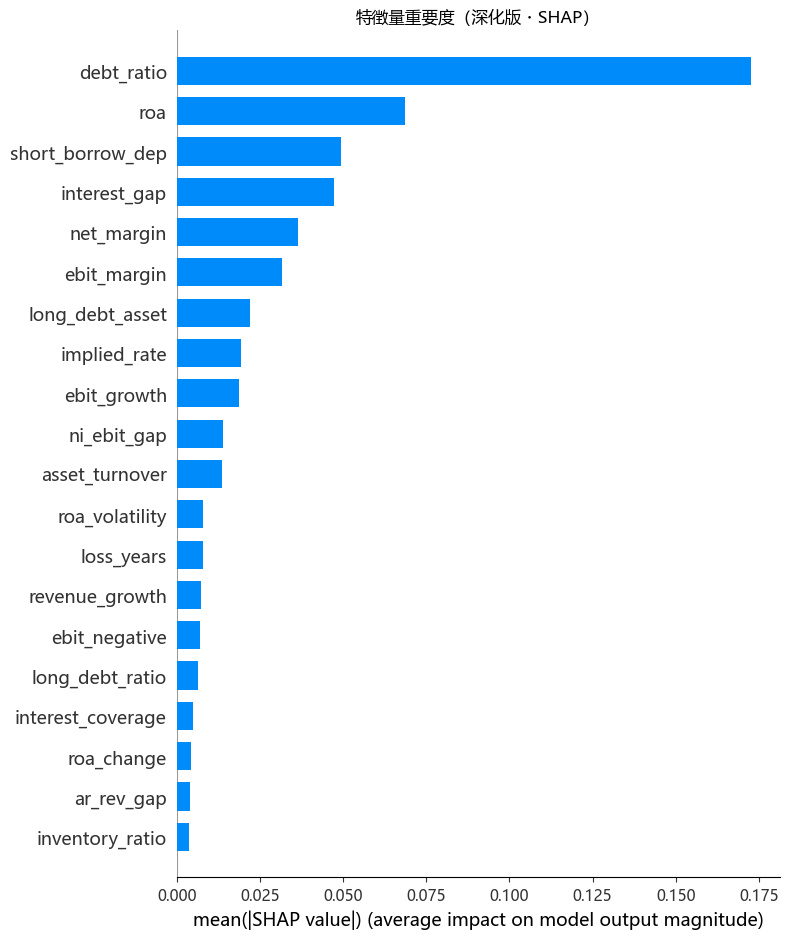

全26特徴量の重要度ランキング:
 1. debt_ratio           0.1727  
 2. roa                  0.0685  
 3. short_borrow_dep     0.0493  
 4. interest_gap         0.0472  
 5. net_margin           0.0364  ★新規
 6. ebit_margin          0.0316  ★新規
 7. long_debt_asset      0.0220  
 8. implied_rate         0.0194  
 9. ebit_growth          0.0188  
10. ni_ebit_gap          0.0140  ★新規
11. asset_turnover       0.0135  ★新規
12. roa_volatility       0.0079  
13. loss_years           0.0078  
14. revenue_growth       0.0073  ★新規
15. ebit_negative        0.0071  
16. long_debt_ratio      0.0064  
17. interest_coverage    0.0049  
18. roa_change           0.0043  
19. ar_rev_gap           0.0039  ★新規
20. inventory_ratio      0.0038  
21. interest_burden      0.0028  
22. ar_growth            0.0023  ★新規
23. debt_growth          0.0022  
24. interest_growth      0.0021  
25. is_financial         0.0002  ★新規
26. is_hightech          0.0001  ★新規


In [7]:
import shap
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'MS Gothic', 'Yu Gothic']
mpl.rcParams['axes.unicode_minus'] = False

X_test_imp = pd.DataFrame(imp.transform(X_test), columns=all_features)
X_sample = X_test_imp.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

shap.summary_plot(sv, X_sample, plot_type='bar', show=False)
plt.title('特徴量重要度（深化版・SHAP）')
plt.tight_layout()
plt.savefig('shap_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 全26特徴量の重要度ランキング（数値で確認）
# ============================================================
import numpy as np

# 各特徴量の平均|SHAP値|を計算
mean_abs_shap = np.abs(sv).mean(axis=0)

# 特徴量名と対応させてソート
importance = pd.DataFrame({
    'feature': all_features,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False).reset_index(drop=True)

# 新規特徴量にマークを付ける
new_features = ['net_margin','ebit_margin','asset_turnover','ni_ebit_gap',
                'revenue_growth','ar_growth','ar_rev_gap','is_hightech','is_financial']
importance['新規'] = importance['feature'].apply(lambda x: '★新規' if x in new_features else '')

print('全26特徴量の重要度ランキング:')
print('='*50)
for i, row in importance.iterrows():
    print(f'{i+1:2d}. {row["feature"]:<20} {row["importance"]:.4f}  {row["新規"]}')

In [8]:
# 特徴量データセットを保存（匿名化済み、公開可能）
save_cols = ['firm','year','label'] + all_features
ml[save_cols].to_csv('ml_dataset_china_deep.csv', index=False, encoding='utf-8-sig')
print(f'保存完了: ml_dataset_china_deep.csv ({len(ml)}行 × {len(save_cols)}列)')

保存完了: ml_dataset_china_deep.csv (29732行 × 29列)
